<a href="https://colab.research.google.com/github/Nikolai-N484/Data201_NikolaiN/blob/main/Project3/Nikolai_Navarro_Project3_Week14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data 201 Final Project**
## **Nikolai Navarro**
## Spring 2026
---

## **Introduction**
Write a short introduction describing:
- Your dataset
- Your prediction goal
- Why the topic is interesting or important
- Possible limitations or bias in the dataset

Include a citation for your dataset source.

I will be reusing the same data set I used for project 1. This dataset was collected by Montgomery County via its Automated Crash Reporting System which includes reports from Maryland state police such as Montgomery County Police, Gaithersburg Police, Rockville Police, or the Maryland-National Capital Park Police. This dataset focuses on traffic collisions involving non-motorists which mean pedestrians and cyclists.

The data provided is updated weekly and may include missing information due to mechanical or human error. Some information may also be missing because of ongoing investigations.

I want to predict the time of the crash using variables from the data set such as the lighting, weather, and road conditions. I chose this topic because it has data about crashes that occur in our county and being able to see what factors play a large role in determine when the crashes occur can help us to understand what we can try to do to prevent these crashes from happening again in the future.

**Citation:**\
“Crash Reporting - Non-Motorists Data: Open Data Portal.” Crash Reporting - Non-Motorists Data | Open Data Portal, Montgomery County, 27 Mar. 2026, data.montgomerycountymd.gov/Public-Safety/Crash-Reporting-Non-Motorists-Data/n7fk-dce5/about_data.

---

## **Dataset and Preparation**

Include:
- Dataset size
- Explanation of variables
- Missing value handling
- Encoding categorical variables if needed
- Train/test split

Include at least one table describing variables.

In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from sklearn.model_selection import train_test_split
import calendar
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

df = pd.read_csv("https://raw.githubusercontent.com/Nikolai-N484/Data201_NikolaiN/refs/heads/main/Crash_Reporting_-_Non-Motorists_Data_20260329.csv")

df.head()

,Report Number,Local Case Number,Agency Name,ACRS Report Type,Crash Date/Time,Route Type,Road Name,Cross-Street Name,Off-Road Description,Municipality,...,Pedestrian Type,Pedestrian Movement,Pedestrian Actions,Pedestrian Location,At Fault,Injury Severity,Safety Equipment,Latitude,Longitude,Location
0,MCP3280007Y,260012513,MONTGOMERY,Injury Crash,03/22/2026 07:30:00 PM,County Route,STEWART LA,OLD COLUMBIA PIKE OLD COLUMBIA PIKE (SB/L),NaN,NaN,...,Pedestrian,Cross/Enter at Intersection,None (No Improper Action),Intersection Marked Crosswalk,No,Possible Injury,NaN,39.046210,-76.986543,"(39.04620981, -76.98654308)"
1,MCP3126007Y,260012218,MONTGOMERY,Injury Crash,03/20/2026 08:01:00 PM,NaN,NaN,NaN,Parking Lot Way MILESTONE SHOPPING CENT...,NaN,...,Pedestrian,Cross/Enter at Intersection,None (No Improper Action),Intersection Marked Crosswalk,No,Suspected Minor Injury,NaN,39.199092,-77.247840,"(39.1990915, -77.24783967)"
2,MCP3126007Y,260012218,MONTGOMERY,Injury Crash,03/20/2026 08:01:00 PM,NaN,NaN,NaN,Parking Lot Way MILESTONE SHOPPING CENT...,NaN,...,Pedestrian,Cross/Enter at Intersection,None (No Improper Action),Intersection Marked Crosswalk,No,No Apparent Injury,NaN,39.199092,-77.247840,"(39.1990915, -77.24783967)"
3,MCP3077002M,260012176,MONTGOMERY,Injury Crash,03/20/2026 03:53:00 PM,County Route,FATHER HURLEY BLVD,NaN,NaN,NaN,...,Pedestrian,Cross/Enter at Intersection,None (No Improper Action),Intersection Marked Crosswalk,No,Possible Injury,NaN,39.191983,-77.272170,"(39.19198337, -77.27216959)"
4,MCP30790088,260011936,MONTGOMERY,Injury Crash,03/19/2026 09:19:00 AM,NaN,NaN,NaN,Parking Aisle PARKING LOT IN FRONT OF L...,NaN,...,Pedestrian,Other,None (No Improper Action),Other,No,Possible Injury,NaN,39.179210,-77.260974,"(39.17920958, -77.26097442)"


| Column | Description | API Field Name | Data Type |
|:-----|:------:|:------:|------:|
|  Report Number  |  ACRS Report Number assigned to the incident.  |  report_number  |  Text  |
|  Local Case Number  |  Case number from the local investigating agency for the incident.  |  local_case_number  |  Text  |
|  Agency Name  |  Name of the investigating agency.  |  agency_name  |  Text  |
|  ACRS Report Type  |  Identifies crash as property, injury, or fatal.  |  acrs_report_type  |  Text  |
|  Crash Date/Time  |  Date and Time of crash.  |  crash_date_time  |  Floating Timestamp  |
|  Route Type  |  Type of roadway at crash location.  |  route_type  |  Text  |
|  Road Name  |  Name of road.  |  road_name  |  Text  |
|  Cross-Street Name  |  Name of nearest cross-street.  |  cross_street_name  |  Text  |
|  Off-Road Description  |  Description of location for off-road collisions.  |  off_road_description  |  Text  |
|  Municipality  |  Jurisdiction for crash location.  |  municipality  |  Text  |
|  Related Non-Motorist  |  Type(s) of non-motorist involved.  |  related_non_motorist  |  Text  |
|  Collision Type  |  Type of collision.  |  collision_type  |  Text  |
|  Weather  |  Weather at collision location.  |  weather  |  Text  |
|  Surface Condition  |  Condition of roadway surface.  |  surface_condition  |  Text  |
|  Light  |  Lighting conditions.  |  light  |  Text  |
|  Traffic Control  |  Signage or traffic control devices.  |  traffic_control  |  Text  |
|  Driver Substance Abuse  |  Substance abuse detected for all drivers involved.  |  driver_substance_abuse  |  Text  |
|  Non-Motorist Substance Abuse  |  Substance abuse detected for this non-motorist.  |  non_motorist_substance_abuse  |  Text  |
|  Person ID  |  Unique identifier for this non-motorist.  |  person_id  |  Text  |
|  Pedestrian Type  |  Type of non-motorist.  |  pedestrian_type  |  Text  |
|  Pedestrian Movement  |  Movement of non-motorist at time of collision.  |  pedestrian_movement  |  Text  |
|  Pedestrian Actions  |  Improper actions by non-motorist.  |  pedestrian_actions  |  Text  |
|  Pedestrian Location  |  Location of non-motorist.  |  pedestrian_location  |  Text  |
|  At Fault  |  Whether this non-motorist was at fault.  |  at_fault  |  Text  |
|  Injury Severity  |  Severity of injury to this non-motorist.  |  injury_severity  |  Text  |
|  Safety Equipment  |  Non-Motorist - Type of safety equipment if any was used.  |  safety_equipment  |  Text  |
|  Latitude  |  Y coordinate of crash location.  |  latitude  |  Number  |
|  Longitude  |  X coordinate of crash location.  |  longitude  |  Number  |
|  Location  |  Location  |  geolocation  |  Location  |

In [154]:
shape = df.shape
print(shape)

(7147, 29)


In [155]:
df["Crash_Month"] = pd.to_datetime(df["Crash Date/Time"]).dt.month
df["Crash_Day"] = pd.to_datetime(df["Crash Date/Time"]).dt.day
df["Crash_Year"] = pd.to_datetime(df["Crash Date/Time"]).dt.year
df["Crash_Time"] = pd.to_datetime(df["Crash Date/Time"]).dt.time
df["Crash_Hour"] = pd.to_datetime(df["Crash Date/Time"]).dt.hour

df.head()

/tmp/ipykernel_13554/2788162730.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Crash_Month"] = pd.to_datetime(df["Crash Date/Time"]).dt.month
/tmp/ipykernel_13554/2788162730.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Crash_Day"] = pd.to_datetime(df["Crash Date/Time"]).dt.day
/tmp/ipykernel_13554/2788162730.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Crash_Year"] = pd.to_datetime(df["Crash Date/Time"]).dt.year
/tmp/ipykernel_13554/2788162730.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back 

,Report Number,Local Case Number,Agency Name,ACRS Report Type,Crash Date/Time,Route Type,Road Name,Cross-Street Name,Off-Road Description,Municipality,...,Injury Severity,Safety Equipment,Latitude,Longitude,Location,Crash_Month,Crash_Day,Crash_Year,Crash_Time,Crash_Hour
0,MCP3280007Y,260012513,MONTGOMERY,Injury Crash,03/22/2026 07:30:00 PM,County Route,STEWART LA,OLD COLUMBIA PIKE OLD COLUMBIA PIKE (SB/L),NaN,NaN,...,Possible Injury,NaN,39.046210,-76.986543,"(39.04620981, -76.98654308)",3,22,2026,19:30:00,19
1,MCP3126007Y,260012218,MONTGOMERY,Injury Crash,03/20/2026 08:01:00 PM,NaN,NaN,NaN,Parking Lot Way MILESTONE SHOPPING CENT...,NaN,...,Suspected Minor Injury,NaN,39.199092,-77.247840,"(39.1990915, -77.24783967)",3,20,2026,20:01:00,20
2,MCP3126007Y,260012218,MONTGOMERY,Injury Crash,03/20/2026 08:01:00 PM,NaN,NaN,NaN,Parking Lot Way MILESTONE SHOPPING CENT...,NaN,...,No Apparent Injury,NaN,39.199092,-77.247840,"(39.1990915, -77.24783967)",3,20,2026,20:01:00,20
3,MCP3077002M,260012176,MONTGOMERY,Injury Crash,03/20/2026 03:53:00 PM,County Route,FATHER HURLEY BLVD,NaN,NaN,NaN,...,Possible Injury,NaN,39.191983,-77.272170,"(39.19198337, -77.27216959)",3,20,2026,15:53:00,15
4,MCP30790088,260011936,MONTGOMERY,Injury Crash,03/19/2026 09:19:00 AM,NaN,NaN,NaN,Parking Aisle PARKING LOT IN FRONT OF L...,NaN,...,Possible Injury,NaN,39.179210,-77.260974,"(39.17920958, -77.26097442)",3,19,2026,09:19:00,9


In [156]:
predictor_cols = ["Pedestrian Actions", "Weather", "Light", "Surface Condition", "Collision Type"]

df = df.dropna(subset = ["Crash_Hour"] + predictor_cols)
shape2 = df.shape
print(shape2)

na = df.isna().sum()
print(na)

(4856, 34)
Report Number                      0
Local Case Number                  0
Agency Name                        0
ACRS Report Type                   0
Crash Date/Time                    0
Route Type                        60
Road Name                        175
Cross-Street Name                614
Off-Road Description            4856
Municipality                    4329
Related Non-Motorist               0
Collision Type                     0
Weather                            0
Surface Condition                  0
Light                              0
Traffic Control                  318
Driver Substance Abuse           627
Non-Motorist Substance Abuse     678
Person ID                          0
Pedestrian Type                    0
Pedestrian Movement               90
Pedestrian Actions                 0
Pedestrian Location               44
At Fault                         185
Injury Severity                    0
Safety Equipment                1988
Latitude                   

After cleaning the data set to remove any NA's for the variables I plan to use and creating new variables to seperate the time and date there is a total of 4856 rows and 33 columns.

In [157]:
X = df[predictor_cols]
y = df["Crash_Hour"]

X_encoded = pd.get_dummies(X, columns = predictor_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size = 0.2, random_state = 42)

print(f"Features shape: {X_encoded.shape}")
print(f"Target rows: {len(y)}")

Features shape: (4856, 145)
Target rows: 4856


---
## **Exploratory Data Analysis**

Create:
- **2 meaningful visualizations**
- Short interpretations

Discuss:
- Interesting patterns
- Trends
- Possible relationships

Keep this section concise.

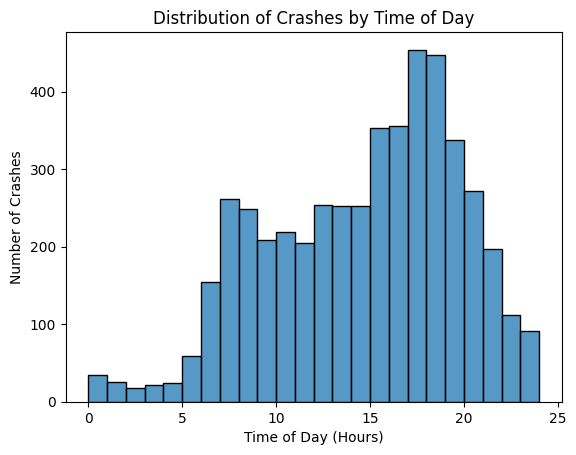

In [158]:
df["Crash_Time_in_hours"] = df["Crash_Time"].apply(lambda d: d.hour + d.minute/60 + d.second/3600)
sns.histplot(df["Crash_Time_in_hours"], bins=24)
plt.xlabel("Time of Day (Hours)")
plt.ylabel("Number of Crashes")
plt.title("Distribution of Crashes by Time of Day")
plt.show()

This histogram shows that crashes are more likely to occur between 4pm to 8pm as most of the data gathers between those two points and can be explained due to rush hour being between those hours where everyone is coming home from school or work. Very little crashes occur early in the day between 1 am to 6 am as most people will be asleep then.

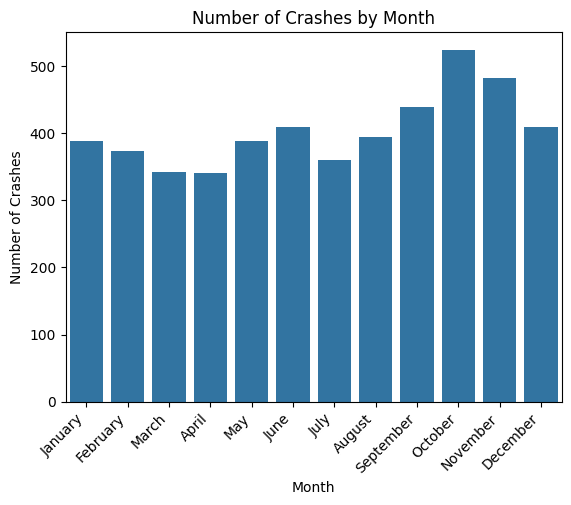

In [159]:
month_counts = df["Crash_Month"].value_counts().sort_index()
month_names = [calendar.month_name[m] for m in month_counts.index]

sns.barplot(x=month_names, y=month_counts.values)
plt.title("Number of Crashes by Month")
plt.xlabel("Month")
plt.ylabel("Number of Crashes")
plt.xticks(rotation=45, ha='right')
plt.show()

Crashes are more likely to occur in the later months with October being the month with the most reported crashes occurring.  This can be due to weather conditions such as increased chances of snow or the earlier nights that occur due to daylight savings and the time change in the later half of the year.

---
## **Decision Tree Analysis (Core Section)**

This is the most important section of the project.

You must:
- Train a Decision Tree Regressor
- Try at least **two different tree depths**
- Briefly discuss possible overfitting
- Include a visualization or diagram of your tree

Also explain:
- The root node
- One important split
- One example prediction path

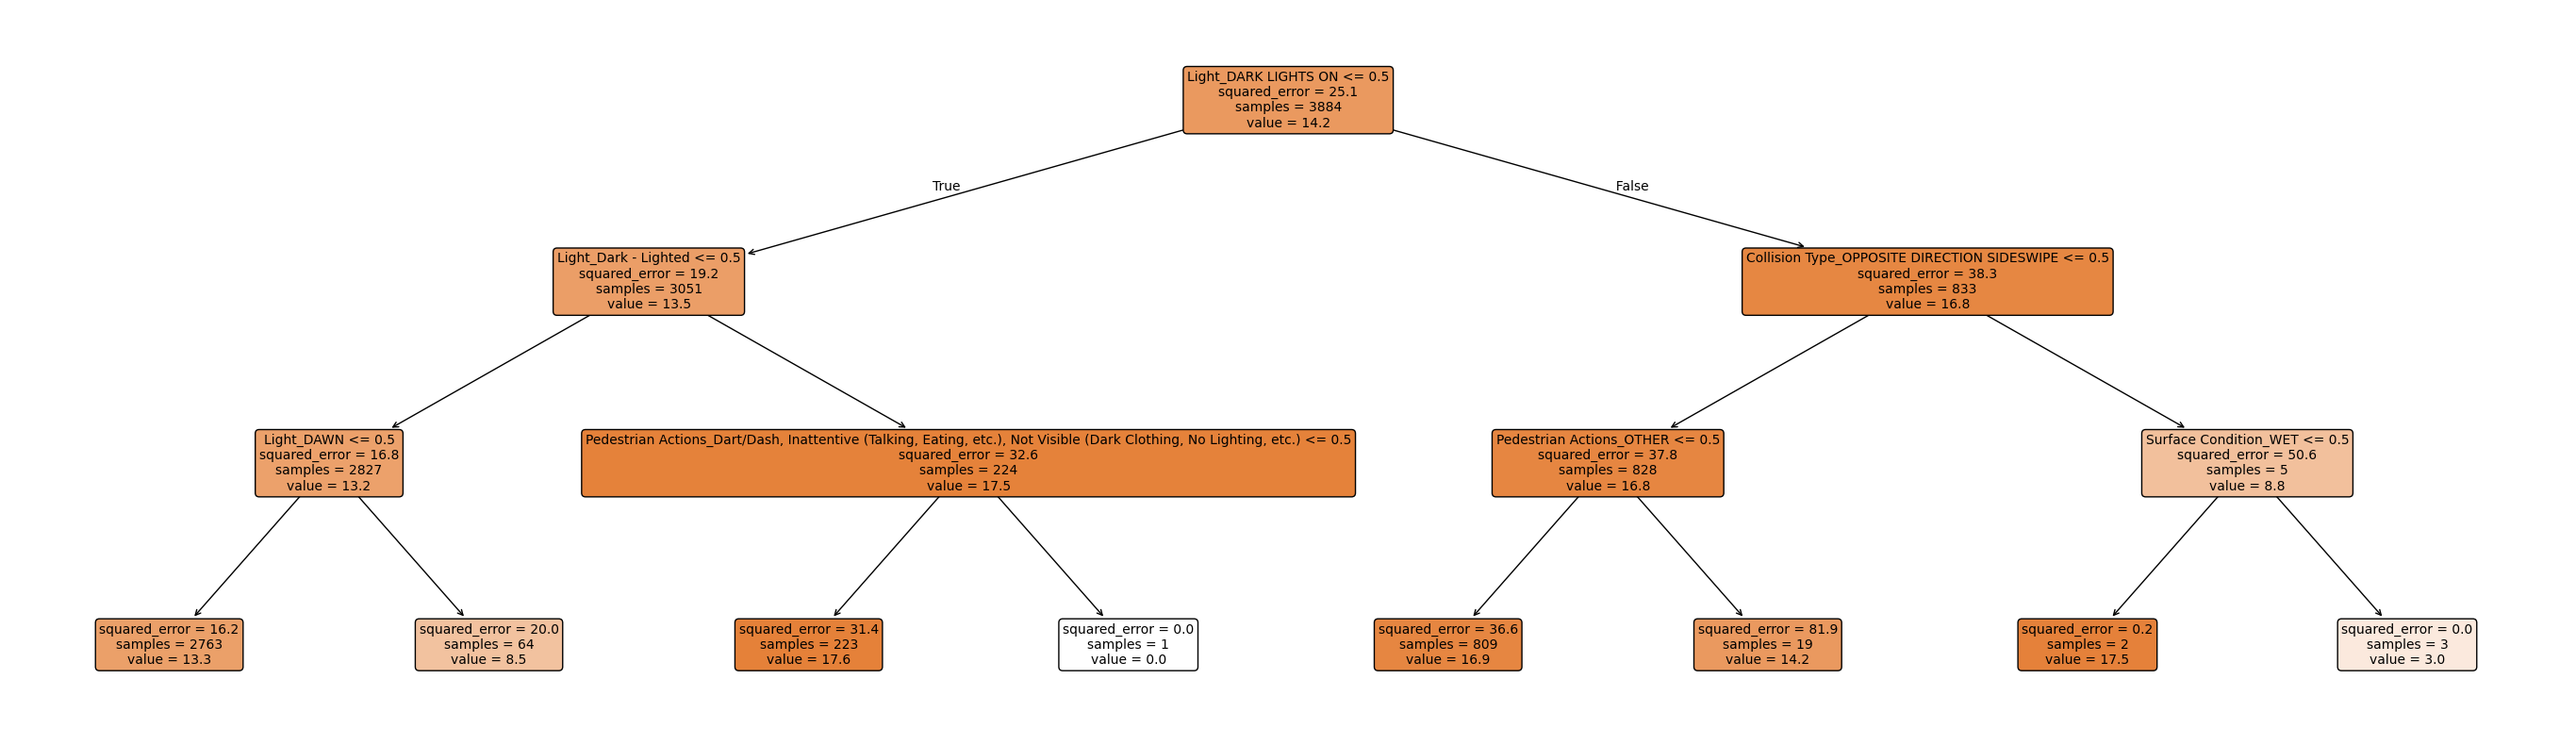

In [165]:
dt_model1 = DecisionTreeRegressor(max_depth = 3, random_state = 42)

dt_model1.fit(X_train, y_train)

plt.figure(figsize = (35, 10))
plot_tree(dt_model1, filled = True, feature_names = list(X_train.columns), max_depth = 3, rounded = True, fontsize = 10, precision = 1)
plt.show()

In [166]:
dt_model2 = DecisionTreeRegressor(max_depth = 10, random_state = 42)

dt_model2.fit(X_train, y_train)


DecisionTreeRegressor(max_depth=10, random_state=42)

--- Decision Tree Depth Comparison ---
Metric          | Depth 3    | Depth 10  
----------------------------------------
Train R^2       | 0.1369     | 0.2430
Test R^2        | 0.1156     | 0.1338


---
## **Ensemble Models**

Train:
- Random Forest
- Gradient Boosting

Compare them to your single decision tree.

Discuss:
- Did performance improve?
- Which model generalized better?
- Which model was easier to explain?

You are NOT expected to perform advanced hyperparameter tuning.

---
## **Model Evaluation**

You must include:

| Metric | Meaning |
|---|---|
| MSE | Lower is better |
| \(R^2\) | Higher is better |

Include:
- A comparison table
- Actual vs Predicted visualization
- Short interpretation of results

---
## **Feature Importance**

For at least one ensemble model:
- Display feature importance
- Identify the top 3 most important features

Important:
- Feature importance does NOT prove causation

---
## **Final Reflection: The Model Battle**

Answer the following questions:

1. Which model performed best?
2. Which model was easiest to explain?
3. Which model would you choose in a real-world setting and why?